<a href="https://colab.research.google.com/github/SofiaFreiman/Lung_epitelium/blob/main/Cell_type_analysis_(manuscript_plots_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --force-reinstall -v "scipy==1.13"
!pip install scanpy leidenalg scikit-misc adjustText==0.8 gseapy==1.1.3 bbknn
import os
os.kill(os.getpid(), 9)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import os
import re
import pandas as pd
import numpy as np
import scipy.stats
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy
from collections import Counter

sc.settings.verbosity = 1
sns.set(font_scale = 1.5)
sns.set_style("whitegrid")

plt.rcParams['font.family'] = 'Liberation Serif'

In [2]:
l2_colors = {'Basal cells': 'tab:green', 'Suprabasal cells': 'darkseagreen', 'Goblet cells': 'mediumaquamarine', 'Secretory cells': 'burlywood', 'Ciliated cells': 'mediumpurple', 'Ionocytes': 'orangered', 'Deuterosomal cells': 'deeppink'}
l3_colors = {'Basal cells' : "tab:green", 'Suprabasal cells' : "darkseagreen", "Goblet cells" : "mediumaquamarine", "Secretory cells" : "burlywood", "Multi-ciliated cells 1" : "cornflowerblue", "Multi-ciliated cells 2" : "mediumpurple", "Ionocytes" : "orangered", "Deuterosomal cells" : "deeppink"}

path = "drive/MyDrive/LU/Pavan_data/"
path_figs = "drive/MyDrive/LU/Pavan_data/figs/"
path_DE = "drive/MyDrive/LU/Pavan_data/DEGs/"
path_figs_svg = "drive/MyDrive/LU/Pavan_data/figs/svg/"

adata = sc.read(path + "adata_current.h5ad")

## overview & marker genes

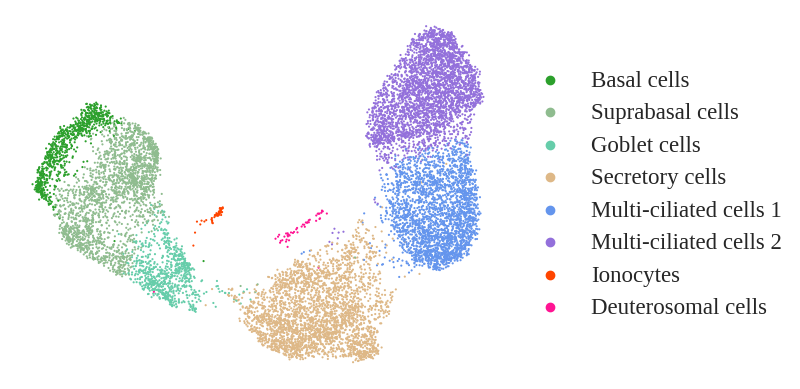

In [18]:
sc.pl.umap(adata, color = ['anno_l3'], title = '', frameon = False, show = False);

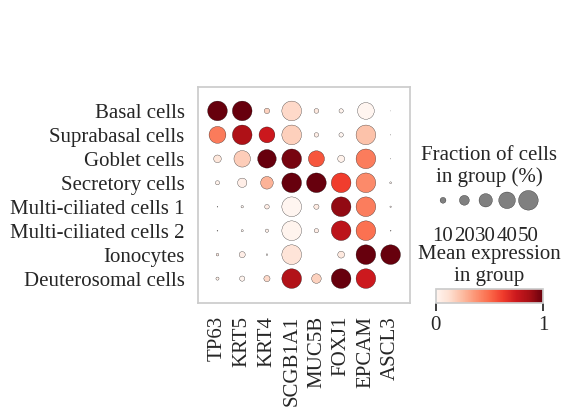

In [17]:
sc.pl.dotplot(adata, ["TP63", "KRT5", "KRT4", "SCGB1A1", "MUC5B", "FOXJ1", "EPCAM", "ASCL3"], groupby="anno_l3", dendrogram=False, dot_max=0.5, standard_scale="var", show = False);

In [23]:
adata.obs['anno_l2'] = adata.obs['anno_l2'].cat.reorder_categories(['Basal cells', 'Suprabasal cells', 'Goblet cells', 'Secretory cells', 'Ciliated cells', 'Ionocytes', 'Deuterosomal cells'])
sc.pp.scale(adata, max_value=10)
adata.layers['scaled'] = adata.X.copy()

350 261


{'heatmap_ax': <Axes: >, 'groupby_ax': <Axes: ylabel='anno_l2'>}

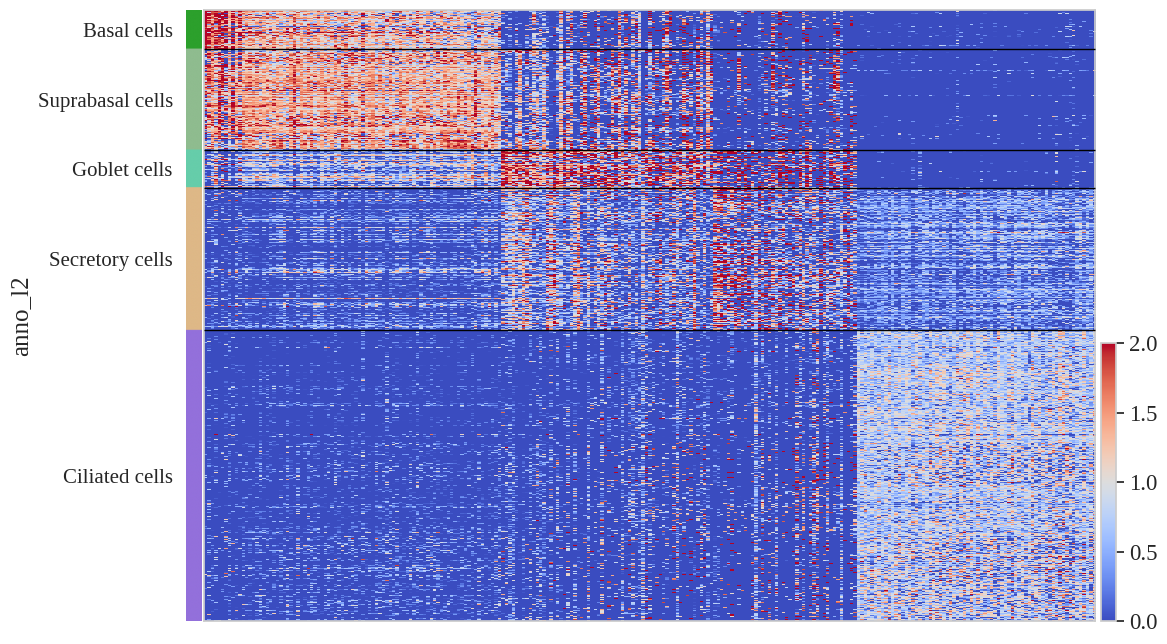

In [25]:
df_ls = []
cell_ls = ['Basal_vs_ALL.csv', 'Suprabasal_vs_ALL.csv', 'Goblet_vs_ALL.csv', 'Secretory_vs_ALL.csv', 'Ciliated_vs_ALL.csv']
for i in cell_ls:
  tmp = pd.read_csv("drive/MyDrive/LU/Pavan_data/DEGs/" + i, index_col = 0).sort_values("scores", ascending = False)
  tmp = tmp[tmp['pct_dropout_by_counts'] < 95]
  df_ls.append(tmp)
len(df_ls)

n_genes = 70
gene_set = []
for df in df_ls:
  gene_set += list(df.index[:n_genes])
gene_set_unique = []
for i in gene_set:
  if i not in gene_set_unique:
    gene_set_unique.append(i)
print(len(gene_set), len(gene_set_unique))

sc.pl.heatmap(adata[~adata.obs['anno_l2'].isin(['Ionocytes', 'Deuterosomal cells'])], gene_set_unique, groupby='anno_l2', swap_axes=False, cmap = 'coolwarm', vmin = 0, vmax = 2, show = False, figsize = (12, 8))

In [26]:
adata.X = adata.layers['lognorm'].copy()

## GSEA for cell types

In [37]:
# Read pre-calculated DEG data

basal = pd.read_csv(path_DE + "Basal_vs_ALL.csv", index_col = 'names')
suprabasal = pd.read_csv(path_DE + "Suprabasal_vs_ALL.csv", index_col = 'names')
goblet = pd.read_csv(path_DE + "Goblet_vs_ALL.csv", index_col = 'names')
secretory = pd.read_csv(path_DE + "Secretory_vs_ALL.csv", index_col = 'names')
ciliated = pd.read_csv(path_DE + "Ciliated_vs_ALL.csv", index_col = 'names')
ionocyte = pd.read_csv(path_DE + "Ionocytes_vs_ALL.csv", index_col = 'names')
deuterosomal = pd.read_csv(path_DE + "Deuterosomal_vs_ALL.csv", index_col = 'names')

basal_rnk = basal[['scores']].sort_values('scores', ascending = False)
suprabasal_rnk = suprabasal[['scores']].sort_values('scores', ascending = False)
goblet_rnk = goblet[['scores']].sort_values('scores', ascending = False)
secretory_rnk = secretory[['scores']].sort_values('scores', ascending = False)
ciliated_rnk = ciliated[['scores']].sort_values('scores', ascending = False)
ionocyte_rnk = ionocyte[['scores']].sort_values('scores', ascending = False)
deuterosomal_rnk = deuterosomal[['scores']].sort_values('scores', ascending = False)

In [28]:
# Calculate pre-rank (based on Wilcoxon score) GSEA for each cell type

gene_set = ['GO_Biological_Process_2023', 'MSigDB_Hallmark_2020', 'GO_Cellular_Component_2023']

print("Basal cells")
basal_gsea_res = gseapy.prerank(rnk = basal_rnk, gene_sets=gene_set, seed = 6, permutation_num = 1000).res2d
basal_gsea_res["Cell type"] = 'Basal cells'
print("Suprabasal cells")
suprabasal_gsea_res = gseapy.prerank(rnk = suprabasal_rnk, gene_sets=gene_set, seed = 6, permutation_num = 1000).res2d
suprabasal_gsea_res["Cell type"] = 'Suprabasal cells'
print("Goblet cells")
goblet_gsea_res = gseapy.prerank(rnk = goblet_rnk, gene_sets=gene_set, seed = 6, permutation_num = 1000).res2d
goblet_gsea_res["Cell type"] = 'Goblet cells'
print("Secretory cells")
secretory_gsea_res = gseapy.prerank(rnk =secretory_rnk, gene_sets=gene_set, seed = 6, permutation_num = 1000).res2d
secretory_gsea_res["Cell type"] = 'Secretory cells'
print("Ciliated cells")
ciliated_gsea_res = gseapy.prerank(rnk = ciliated_rnk, gene_sets=gene_set, seed = 6, permutation_num = 1000).res2d
ciliated_gsea_res["Cell type"] = 'Ciliated cells'
print("Ionocytes")
ionocyte_gsea_res = gseapy.prerank(rnk = ionocyte_rnk, gene_sets=gene_set, seed = 6, permutation_num = 1000).res2d
ionocyte_gsea_res["Cell type"] = 'Ionocytes'
print("Deuterosomal cells")
deuterosomal_gsea_res = gseapy.prerank(rnk = deuterosomal_rnk, gene_sets=gene_set, seed = 6, permutation_num = 1000).res2d
deuterosomal_gsea_res["Cell type"] = 'Deuterosomal cells'

2025-05-30 12:50:16,521 [WARNING] Duplicated values found in preranked stats: 17.28% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Basal cells


2025-05-30 12:52:12,788 [WARNING] Duplicated values found in preranked stats: 7.84% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Suprabasal cells


2025-05-30 12:53:39,897 [WARNING] Duplicated values found in preranked stats: 12.07% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


...

Ciliated cells


2025-05-30 12:57:52,304 [WARNING] Duplicated values found in preranked stats: 34.99% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Ionocytes


2025-05-30 12:59:16,452 [WARNING] Duplicated values found in preranked stats: 31.64% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Deuterosomal cells


In [29]:
## Ionocytes and Deuterosomal excluded

df_dict = {'Basal cells' : basal_gsea_res,
           "Suprabasal cells" : suprabasal_gsea_res,
           "Goblet cells" : goblet_gsea_res,
           "Secretory cells" : secretory_gsea_res,
           "Ciliated cells" : ciliated_gsea_res,
           }

for cell_type in df_dict.keys():
  df_dict[cell_type]['gene set'] = df_dict[cell_type]['Term'].str.extract(r'(.*?\d{4})')
  df_dict[cell_type]['Term_name'] = df_dict[cell_type]['Term'].str.extract(r'\d{4}__([\s\S]*)')


for cell_type in df_dict.keys():
    df_dict[cell_type]['Term_name'] = df_dict[cell_type].apply(
        lambda row: f"{row['Term_name']} (HallmarkDB)" if row['gene set'] == 'MSigDB_Hallmark_2020' else row['Term_name'], axis=1)

In [33]:
df_dict['Basal cells'][:2]

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,Cell type,gene set,Term_name
0,prerank,GO_Biological_Process_2023__Cytoplasmic Transl...,0.965975,3.09232,0.0,0.0,0.0,79/91,1.58%,RPLP1;RPS27;RPL34;RPL10A;RPL32;RPL13;RPL3;RPS9...,Basal cells,GO_Biological_Process_2023,Cytoplasmic Translation (GO:0002181)
1,prerank,GO_Cellular_Component_2023__Large Ribosomal Su...,0.980526,3.003977,0.0,0.0,0.0,44/48,0.59%,RPLP1;RPL34;RPL10A;RPL32;RPL13;RPL3;RPL13A;RPL...,Basal cells,GO_Cellular_Component_2023,Large Ribosomal Subunit (GO:0015934)


In [38]:
# For each gene set collection find the pathways changed in all cell types (1) or at least in N of chosen cell types

# db = "GO_Biological_Process_2023"
# db = 'GO_Molecular_Function_2023'
db = 'MSigDB_Hallmark_2020'
# db = 'GO_Cellular_Component_2023'

db_dict = {}
for cell_type, data in df_dict.items():
  tmp = data[data['gene set'] == db].copy()
  tmp = tmp[tmp['FDR q-val'] < 0.05]
  db_dict[cell_type] = tmp['Term_name'].to_list()

# Get the intersection of Term_name across all cell types
all_term_names = set.intersection(*[set(terms) for terms in db_dict.values()])
print("Intersection across all cell types:")
print(all_term_names)

N=2
all_terms = [term for terms in db_dict.values() for term in terms] # Flatten the lists of Term_name from all cell types
term_counts = Counter(all_terms) # Count the occurrences of each Term_name
terms_in_at_least_N = [term for term, count in term_counts.items() if count >= N]
print(f"Terms appearing in at least {N} cell types:")
print(len(terms_in_at_least_N))
print(terms_in_at_least_N)

Intersection across all cell types:
set()
Terms appearing in at least 2 cell types:
4
['TNF-alpha Signaling via NF-kB (HallmarkDB)', 'p53 Pathway (HallmarkDB)', 'Estrogen Response Late (HallmarkDB)', 'Inflammatory Response (HallmarkDB)']


In [ ]:
selected_cell_types = ['Basal cells', 'Suprabasal cells', 'Goblet cells']#, 'Secretory cells', 'Ciliated cells']
selected_term_names = set.intersection(*[set(db_dict[cell_type]) for cell_type in selected_cell_types]) # Get the intersection of Term_name for the selected cell types
print(f"Intersection between {selected_cell_types}:")
print(len(selected_term_names))
print(selected_term_names)

Intersection between ['Basal cells', 'Suprabasal cells', 'Goblet cells']:
1
{'TNF-alpha Signaling via NF-kB (HallmarkDB)'}


In [39]:
## Final list of chosen pathways

terms_GO = [
            "Peptide Biosynthetic Process (GO:0043043)", 'Ribosome Assembly (GO:0042255)', 'Cytoplasmic Translation (GO:0002181)',
            "Cilium Organization (GO:0044782)", 'Cilium Movement (GO:0003341)', "Cilium Assembly (GO:0060271)", 'Organelle Assembly (GO:0070925)', 'Cilium-Dependent Cell Motility (GO:0060285)', 'Microtubule Bundle Formation (GO:0001578)',
            ]
terms_GO_Cell = ['Large Ribosomal Subunit (GO:0015934)', 'Small Ribosomal Subunit (GO:0015935)',]
terms_HM = ['TNF-alpha Signaling via NF-kB', 'p53 Pathway', 'IL-6/JAK/STAT3 Signaling', 'Myc Targets V1', 'Oxidative Phosphorylation']
terms_HM = [i + " (HallmarkDB)" for i in terms_HM]

Text(0.5, 0, '')

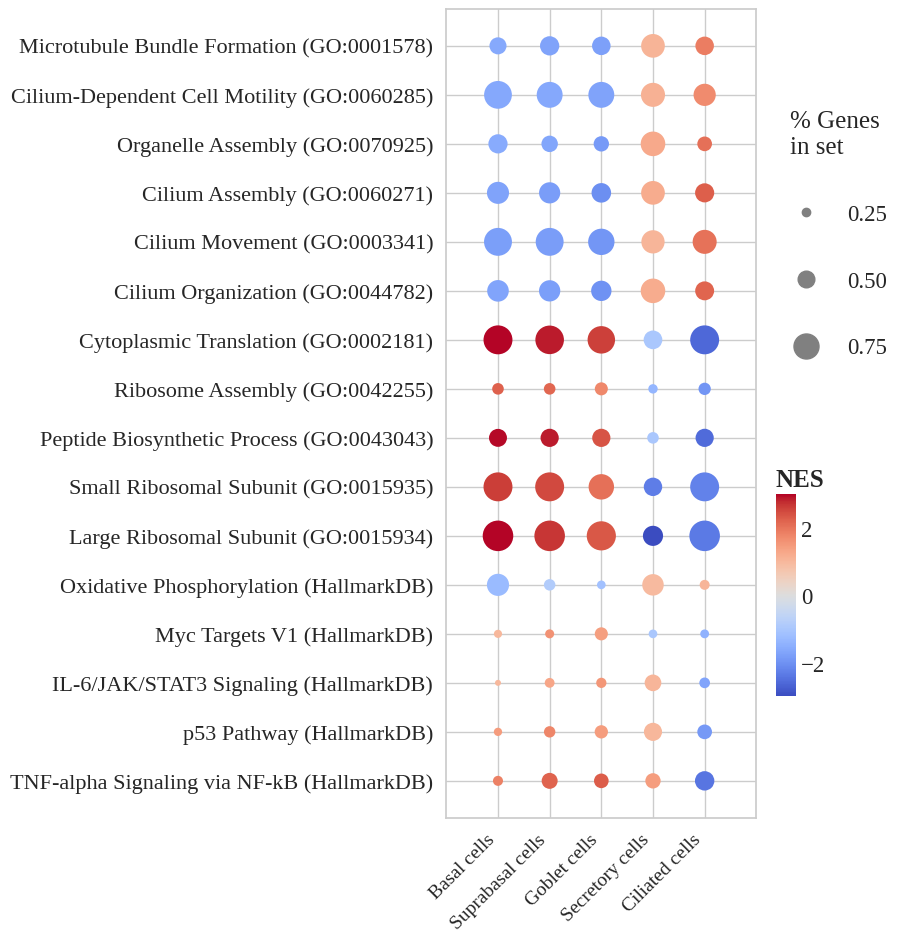

In [40]:
res_df = pd.concat(df_dict.values())
res_df.reset_index(inplace = True)
res_df['Cell type'] = res_df['Cell type'].astype('category')
res_df['Cell type'] = res_df['Cell type'].cat.remove_unused_categories()
res_df['Cell type'] = res_df['Cell type'].cat.reorder_categories(['Basal cells', 'Suprabasal cells', 'Goblet cells', 'Secretory cells', 'Ciliated cells',])
res_df = res_df[res_df["Term_name"].isin(terms_GO+terms_GO_Cell+terms_HM)]
res_df.reset_index(inplace = True)

ax = gseapy.dotplot(res_df,
              column="NES",
              x='Cell type',
              y = "Term_name",
              y_order=terms_HM+terms_GO_Cell+terms_GO,
              size=4,
              top_term=100,
              figsize=(5, 10.5),
              # title = "Cell-type enriched pathways",
              xticklabels_rot=45,
              show_ring=False,
              marker='o',
              cmap = 'coolwarm',
              )
plt.xlabel('')

## Ribosomal protein genes expression

In [41]:
# Retrieve RP genes; remove non-RP; remove not-expressed

ribo = adata.var_names[adata.var['ribo'] == True].to_list()
rpl_ls = [i for i in ribo if "RPL" in i]
rps_ls = [i for i in ribo if "RPS" in i]
print(len(rps_ls), len(rpl_ls))
rps_to_remove = ["RPS6KA5", "RPS6KA1", "RPS6KC1", "RPS6KA2", "RPS6KA2-IT1", "RPS10-NUDT3", "RPS6KB2", "RPS6KA4", "RPS6KB2-AS1", "RPS6KL1", "RPS6KB1", "RPS19BP1", "RPS6KA6", "RPS6KA3", "RPS4Y1"]
rpl_to_remove = ["RPL34-AS1", "RPL3L", "RPL7L1",]
rps_ls = [i for i in rps_ls if i not in rps_to_remove]
rpl_ls = [i for i in rpl_ls if i not in rpl_to_remove]
print(len(rps_ls), len(rpl_ls))

47 53
32 50


In [44]:
rps_gene_order = ['RPS2', 'RPS3', 'RPS3A', 'RPS4X', 'RPS5', 'RPS6', 'RPS7', 'RPS8', 'RPS9', 'RPS10', 'RPS11', 'RPS12', 'RPS13', 'RPS14', 'RPS15', 'RPS15A', 'RPS16', 'RPS17', 'RPS18', 'RPS19', 'RPS20',
                  'RPS21', 'RPS23', 'RPS24', 'RPS25', 'RPS26', 'RPS27', 'RPS27A', 'RPS27L', 'RPS28', 'RPS29', 'RPSA',]
rpl_gene_order = ['RPL3', 'RPL4', 'RPL5', 'RPL6', 'RPL7', 'RPL7A', 'RPL8', 'RPL9', 'RPL10', 'RPL10A', 'RPL11', 'RPL12', 'RPL13', 'RPL13A', 'RPL14', 'RPL15', 'RPL17', 'RPL18A', 'RPL18', 'RPL19',
                  'RPL21', 'RPL22', 'RPL22L1', 'RPL23', 'RPL23A', 'RPL24', 'RPL26', 'RPL26L1', 'RPL27', 'RPL27A', 'RPL28', 'RPL29',
                  'RPL30', 'RPL31', 'RPL32', 'RPL34', 'RPL35', 'RPL35A', 'RPL36', 'RPL36A', 'RPL36AL', 'RPL37', 'RPL37A', 'RPL38', 'RPL39', 'RPL39L', 'RPL41', 'RPLP0', 'RPLP1', 'RPLP2',]

ct_order = {
    'Basal cells' : 0,
    'Suprabasal cells' : 1,
    'Goblet cells' : 2,
    'Secretory cells' : 3,
    'Multi-ciliated cells 1' : 4,
    'Multi-ciliated cells 2' : 5,
    'Deuterosomal cells' : 6,
    'Ionocytes' : 7
    }

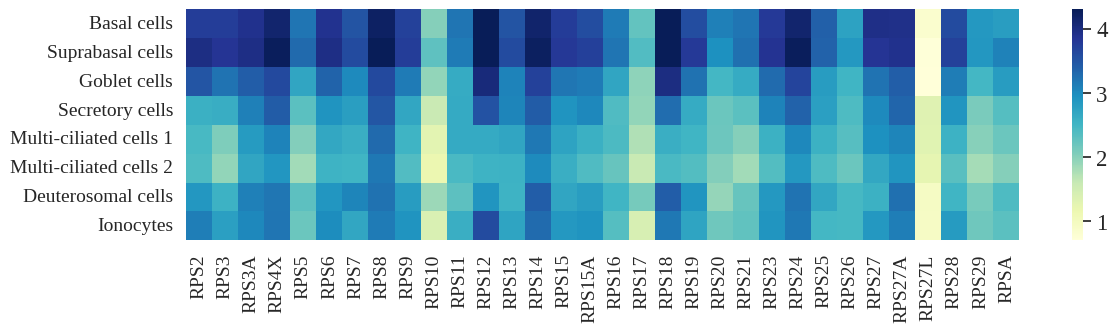

In [45]:
heatmap_col = 'anno_l3'
subset = adata[:, rps_ls]
set(subset.obs['anno_l3'])

ct_df = pd.DataFrame({"ct" : ct_order.keys(), "order" : ct_order.values()})
ct_df.set_index("ct", inplace = True)

mean_expr = pd.DataFrame(columns = subset.var_names, index = subset.obs[heatmap_col].cat.categories)

for cell_group in subset.obs[heatmap_col].cat.categories:
    mean_expr.loc[cell_group] = subset[(subset.obs[heatmap_col].isin([cell_group])),:].X.mean(0)

mean_expr = mean_expr.merge(ct_df, left_index = True, right_index = True, how = "outer")
mean_expr.sort_values(by = "order", inplace = True)
del mean_expr['order']
mean_expr = mean_expr[rps_gene_order]
mean_expr=mean_expr.astype('float')

fig, ax = plt.subplots(ncols = 1, nrows = 1, figsize = (len(rps_gene_order)*0.42, 3))

sns.heatmap(mean_expr, cmap="YlGnBu", ax=ax, vmax = 4.3)

ax.set_ylabel(''); ax.set_xlabel('')
ax.tick_params(axis='both', labelsize=14)

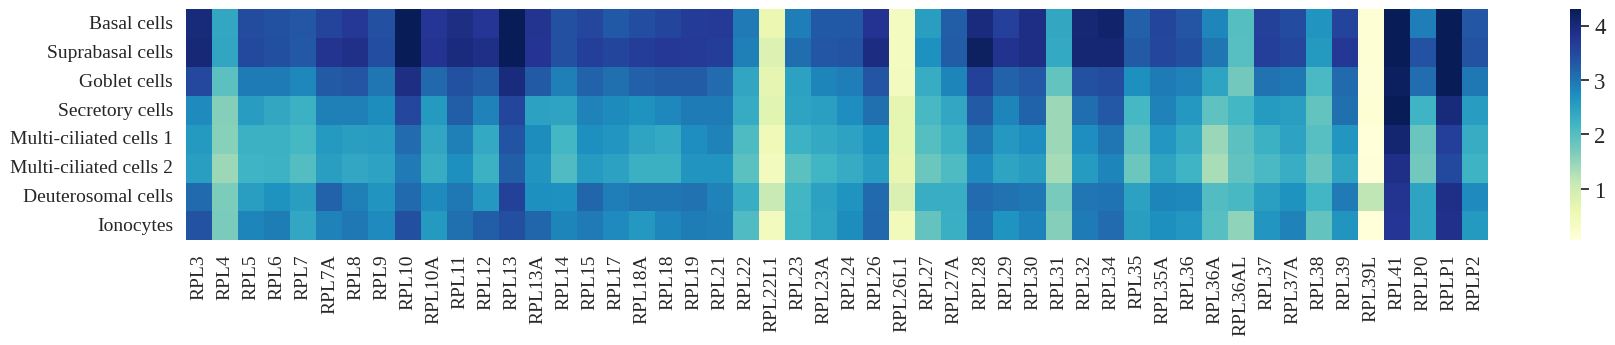

In [46]:
heatmap_col = 'anno_l3'
subset = adata[:, rpl_ls]
set(subset.obs['anno_l3'])

ct_df = pd.DataFrame({"ct" : ct_order.keys(), "order" : ct_order.values()})
ct_df.set_index("ct", inplace = True)

mean_expr = pd.DataFrame(columns = subset.var_names, index = subset.obs[heatmap_col].cat.categories)

for cell_group in subset.obs[heatmap_col].cat.categories:
    mean_expr.loc[cell_group] = subset[(subset.obs[heatmap_col].isin([cell_group])),:].X.mean(0)

mean_expr = mean_expr.merge(ct_df, left_index = True, right_index = True, how = "outer")
mean_expr.sort_values(by = "order", inplace = True)
del mean_expr['order']
# mean_expr=mean_expr.transpose()
mean_expr = mean_expr[rpl_gene_order]
mean_expr=mean_expr.astype('float')

fig, ax = plt.subplots(ncols = 1, nrows = 1, figsize = (len(rpl_gene_order)*0.42, 3))

sns.heatmap(mean_expr, cmap="YlGnBu", ax=ax, vmax = 4.3)

ax.set_ylabel(''); ax.set_xlabel('')
ax.tick_params(axis='both', labelsize=14)

In [47]:
# Calculate Ribo score

adata.X = adata.layers['lognorm'].copy()
ribo = rps_ls + rpl_ls
print(len(ribo))
sc.tl.score_genes(adata, ribo, ctrl_size=500, n_bins=50, score_name='ribo_score', random_state=0, copy=False)

82


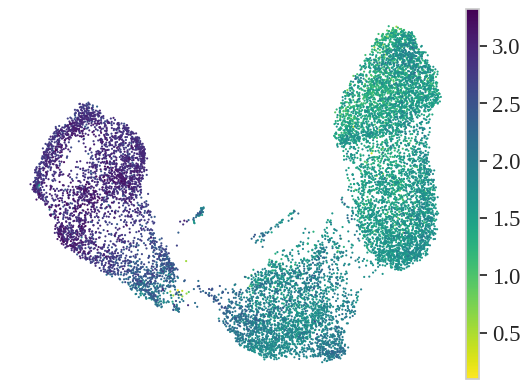

In [49]:
sc.pl.umap(adata, color = 'ribo_score', cmap = "viridis_r", title = '', frameon = False, show = False);